# Tail Diagnosis of PRISM IC50 Responses

## Censoring, Curve-Fit Quality, and Extreme Responses

This notebook investigates the extreme values observed in the PRISM IC50 response data used for the pancreatic cancer drug-response prediction study.

The integrated pancreatic dataset contains a highly skewed distribution of log10(IC50) values, including extremely large positive and negative values. Before developing a censoring-aware prediction model, these observations must be diagnosed rather than automatically removed or labelled as artifacts.

The analysis therefore examines:

1. The distribution of log10(IC50) responses.
2. The relationship between extreme IC50 values and curve-fit quality (R²).
3. The relationship between IC50 and the experimentally tested dose range.
4. AUC as an additional response-quality/context measure.
5. The prevalence of potentially censored observations.
6. Whether extreme responses are concentrated in particular drugs or cell lines.

The purpose is to determine whether the observed long tail is consistent with dose-range censoring and/or poor curve fitting, while preserving the possibility that some extreme responses represent genuine biological observations.

The findings from this notebook will determine whether a censoring-aware target and loss function are scientifically justified in the subsequent modelling stages.

## Research Questions

This notebook addresses the following questions:

### Q1. How extreme is the IC50 distribution?

What is the distribution of log10(IC50), and how much of the data lies in the extreme tails?

### Q2. Are extreme IC50 values associated with poor curve fitting?

Do observations with very large or very small IC50 values have systematically lower R² values?

### Q3. Are extreme IC50 values outside the experimentally tested dose range?

If the actual tested concentration range is available, does the estimated IC50 fall outside that range?

### Q4. Are extreme observations associated with different AUC behaviour?

AUC will be examined as an additional response descriptor rather than as direct proof of censoring.

### Q5. Are the extreme observations concentrated in particular drugs?

If a small number of drugs account for a large proportion of extreme observations, this may indicate drug-specific response or assay/curve-fitting behaviour.

### Q6. Is there sufficient evidence to motivate censoring-aware modelling?

The goal is not to assume that the long tail is an artifact. The goal is to determine whether the data provide evidence consistent with censoring or unreliable extrapolation.

## Analysis Strategy

The diagnosis will be performed in stages.

First, the raw PRISM response file will be inspected to identify the available response, curve-fitting, and dose-related variables.

Second, the pancreatic subset used in the modelling study will be isolated.

Third, IC50 values will be converted to log10(IC50) and extreme observations will be characterized.

Fourth, curve-fit quality will be examined using the reported R² values.

If the raw PRISM data provide the experimentally tested concentration range, the estimated IC50 will be compared with that range to identify observations whose estimated IC50 lies below or above the tested range.

Finally, AUC and drug-level consistency will be examined to determine whether the extreme observations show systematic patterns.

No observation will be removed solely because its IC50 is extreme. Any filtering or target transformation used in later modelling will be justified using the evidence obtained here.

## 1. Data Sources

The project uses several raw datasets. For this diagnostic analysis, the primary source is the PRISM dose-response curve parameter file.

The relevant files are:

- `secondary-screen-dose-response-curve-parameters.csv` — response and dose-response curve parameters.
- `secondary-screen-cell-line-info.csv` — cell-line metadata.

The omics feature files are not required for the present tail diagnosis because this notebook focuses on the quality and distribution of the response labels.

In [1]:
import os

raw_dir = r"D:\Pancreatic_GraphTCDR\data\raw"

print("Files in data/raw:\n")

for file in sorted(os.listdir(raw_dir)):
    print(file)

Files in data/raw:

CNVFeature402.pt
GeneExpressionFeature402.pt
MethylationFeature402.pt
OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
PortalOmicsCNGeneLog2.csv
cellLineName402.csv
miRNAFeature402.pt
secondary-screen-cell-line-info.csv
secondary-screen-dose-response-curve-parameters.csv


## 2. Inspect response columns

The PRISM dose-response curve parameter file is large, so the complete dataset will not initially be loaded.

We first inspect its column structure using only the header.

This step is important because variables such as `upper_limit` and `lower_limit` must not automatically be interpreted as the experimentally tested drug concentration limits. Their meaning will be established from the available PRISM data before they are used in the censoring analysis.

In [2]:
import pandas as pd
response_file = r"D:\Pancreatic_GraphTCDR\data\raw\secondary-screen-dose-response-curve-parameters.csv"
response_headers = pd.read_csv(response_file, nrows=0)
print("Number of Columns:", len(response_headers.columns))
print("\nColumn :")
for i , col in enumerate(response_headers.columns):
    print(f"{i+1}. {col}")

Number of Columns: 20

Column :
1. broad_id
2. depmap_id
3. ccle_name
4. screen_id
5. upper_limit
6. lower_limit
7. slope
8. r2
9. auc
10. ec50
11. ic50
12. name
13. moa
14. target
15. disease.area
16. indication
17. smiles
18. phase
19. passed_str_profiling
20. row_name


## 3. Available Response Variables

The PRISM dose-response curve parameter file contains 20 variables describing the cell line, drug, fitted dose-response curve, and experimental metadata.

The variables relevant to the present analysis include:

- `depmap_id` and `ccle_name` — identify the cancer cell line.
- `name` — identifies the drug/compound.
- `r2` — goodness-of-fit measure for the fitted dose-response curve.
- `auc` — area under the dose-response curve.
- `ec50` — estimated concentration producing a half-maximal response.
- `ic50` — estimated concentration producing a half-maximal response according to the fitted curve.
- `upper_limit` and `lower_limit` — parameters associated with the fitted response curve.

The presence of `upper_limit` and `lower_limit` does not by itself establish that they represent the experimentally tested minimum and maximum drug concentrations.

Therefore, the next step is to inspect their numerical values and compare them with the other dose-response parameters before using them to define censoring boundaries.

For the tail diagnosis, the key variables are therefore:

`IC50 → R² → AUC → dose-related information`

This allows us to distinguish extreme response values from observations that may reflect poor curve fitting or extrapolation beyond the experimentally tested range.

inspect the relevant columns

Inspect the dose-response variables before loading the full dataset

In [3]:
relevant_columns = [
    "upper_limit",
    "lower_limit",
    "slope",
    "r2",
    "auc",
    "ec50",
    "ic50"
]

In [4]:
#read only the relevant columns 
response_sample = pd.read_csv(response_file, usecols=relevant_columns, nrows=10000)
print(response_sample.describe().T)

               count           mean         std         min       25%  \
upper_limit  10000.0   1.000000e+00    0.000000    1.000000  1.000000   
lower_limit  10000.0   1.327102e+00    1.634758   -2.800805  0.312264   
slope        10000.0   1.399496e+00    5.942308 -186.032426 -0.227402   
r2           10000.0   1.908166e-01    0.300195   -1.159078 -0.017967   
auc          10000.0   1.123298e+00    0.364763    0.085928  0.841010   
ec50         10000.0  4.899038e+253         inf    0.000010  0.009532   
ic50          2791.0   1.173026e+01  416.297448    0.000078  0.091825   

                  50%       75%            max  
upper_limit  1.000000  1.000000   1.000000e+00  
lower_limit  1.463440  1.839684   6.298455e+01  
slope        0.004612  1.910936   2.137731e+02  
r2           0.076982  0.382229   9.999715e-01  
auc          1.210285  1.375771   2.568743e+00  
ec50         0.100066  0.650349  4.899038e+257  
ic50         0.431748  0.931877   2.003360e+04  


d:\Pancreatic_GraphTCDR\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


## 4. Understanding the PRISM Curve Parameters

The initial inspection shows that `upper_limit` and `lower_limit` should not be treated as experimental drug-concentration boundaries.

In the PRISM dose-response model, these variables describe limits of the fitted response curve. In particular, `upper_limit` represents the asymptotic upper response level, while `lower_limit` represents the response level approached at low concentration.

Therefore, they cannot be directly used to determine whether an estimated IC50 lies outside the experimentally tested concentration range.

The PRISM secondary screen used an 8-step, 4-fold dilution series beginning at 10 μM. However, the present curve-parameter file does not contain an explicit per-row minimum and maximum tested concentration column.

Consequently, this notebook will not incorrectly infer censoring boundaries from `upper_limit` or `lower_limit`.

Instead, we will first investigate whether extreme IC50 values are associated with poor curve-fitting quality, using R², and then determine whether the available PRISM treatment-level data can provide the actual tested concentration information.

Inspect the observations with the largest finite IC50 values

In [5]:
import numpy as np

In [6]:
extreme_ic50 = response_sample[
    response_sample["ic50"].notna() &
    np.isfinite(response_sample["ic50"])
    ].nlargest(20,"ic50")

print(
    extreme_ic50[["ic50","auc","r2","slope","upper_limit","lower_limit"]].to_string(index=False)
)

        ic50      auc        r2    slope  upper_limit  lower_limit
20033.601521 0.907546 -0.117916 0.264212            1     0.369501
 9072.311299 0.853867 -0.019927 0.175140            1     0.174634
  391.714675 0.847197  0.162884 0.419214            1     0.451726
  257.658490 0.974775  0.055332 0.287431            1    -2.018140
   63.000871 0.989142 -0.109478 1.148405            1     0.060801
   59.497250 0.851429 -0.116313 0.783144            1     0.484483
   58.022526 0.842049  0.288068 0.901488            1     0.492826
   49.123323 0.985562 -0.020724 2.005849            1     0.470697
   42.199137 0.983333  0.088179 0.856585            1    -0.479954
   32.524180 0.979333  0.032077 0.995776            1    -0.198909
   31.704742 0.896411  0.027255 1.405533            1     0.493535
   28.849253 0.906650 -0.092596 0.422929            1    -0.167638
   24.206937 0.919074 -0.031685 0.660669            1     0.190647
   23.543855 0.942328  0.082071 1.432354            1     0.45

## 5. Initial Observation from Extreme IC50 Values

The largest finite IC50 observations show a heterogeneous pattern.

Several of the most extreme IC50 values are associated with very low or negative R² values, indicating poor agreement between the fitted dose-response curve and the observed response data.

However, other large IC50 values have high R² values, including values above 0.90. Therefore, extreme IC50 values cannot be assumed to be fitting artifacts solely because they are numerically large.

This observation motivates a systematic analysis across the complete pancreatic dataset.

The next analysis will quantify the relationship between response magnitude and curve-fitting quality using predefined IC50 ranges.

## 6. Curve-Fit Quality Across IC50 Ranges

To determine whether poor curve fitting becomes more common as IC50 increases, finite IC50 observations are divided into predefined response ranges.

For each range, we calculate:

- Number of observations.
- Median R².
- Mean R².
- Percentage of observations with R² < 0.
- Percentage of observations with R² < 0.2.

Negative R² indicates that the fitted curve performs worse than a constant-mean model under the R² definition used here. A low R² is therefore treated as evidence of poor curve fit, rather than as direct evidence that an IC50 value is biologically invalid.

The analysis is descriptive and does not by itself establish the cause of an extreme IC50.

create IC50 response ranges for the full sample

In [7]:
finite_ic50 = response_sample[
    response_sample["ic50"].notna() &
    np.isfinite(response_sample["ic50"])
].copy()

finite_ic50["ic50_range"] = pd.cut(finite_ic50["ic50"],
    bins=[-np.inf,1,10,100,1000,np.inf],
    labels=["<1","1-10","10-100","100-1000",">1000"])

range_summary = (
    finite_ic50 
    .groupby("ic50_range",observed=False)
    .agg(
        N=("ic50","size"),
        Median_R2=("r2","median"),
        Mean_R2=("r2","mean"),
        R2_negative=("r2", lambda x: (x < 0).mean() * 100),
        R2_below_02=("r2",lambda x: (x<0.2).mean() * 100)
        
    )
    .reset_index()
)

range_summary

,ic50_range,N,Median_R2,Mean_R2,R2_negative,R2_below_02
0,<1,2127,0.655933,0.616518,1.504466,5.265632
1,1-10,639,0.389660,0.343271,10.798122,25.978091
2,10-100,21,0.032077,0.009087,42.857143,76.190476
3,100-1000,2,0.109108,0.109108,0.000000,100.000000
4,>1000,2,-0.068922,-0.068922,100.000000,100.000000


## 7. Interpretation of the Preliminary Curve-Fit Analysis

The preliminary sample shows a clear association between increasing IC50 magnitude and poorer curve-fitting quality.

The median R² decreases substantially as IC50 increases, while the proportion of observations with R² below 0.2 increases.

However, the highest IC50 ranges contain very few observations in this preliminary sample. Therefore, these results are treated only as an initial diagnostic signal and not as a final conclusion.

The same analysis must be repeated on the complete pancreatic subset used in the modelling study.

The key question is whether the relationship between extreme IC50 values and poor R² persists when all observations from the 28 matched pancreatic cell lines are considered.

## 8. Constructing the Final Pancreatic Diagnostic Dataset

The final analysis is restricted to the 28 pancreatic cell lines that were successfully matched to the GraphTCDR multi-omics representation used in the modelling pipeline.

This restriction ensures that the response-quality analysis corresponds exactly to the population on which the downstream prediction models will be evaluated.

Only the variables required for response diagnosis are loaded from the large PRISM response file.

load the 28 GraphTCDR-matched pancretic cell lines

In [8]:
mapping_file = r"D:\Pancreatic_GraphTCDR\data\processed\pancreatic28_cell_mapping.csv"
cell_mapping = pd.read_csv(mapping_file)

print("Mapping shape:",cell_mapping.shape)
print("\nColumns:")
print(cell_mapping.columns.tolist())
display(cell_mapping.head())

Mapping shape: (28, 2)

Columns:
['index', 'cellLineName']


,index,cellLineName
0,0,PATU8988S_PANCREAS
1,39,PANC0327_PANCREAS
2,47,PANC1_PANCREAS
3,68,PSN1_PANCREAS
4,79,SUIT2_PANCREAS


## 9. Loading PRISM Responses for the 28 Matched Cell Lines

The response analysis is now restricted to the 28 pancreatic cell lines that have corresponding GraphTCDR multi-omics features.

The large PRISM response file contains 20 columns, but only a subset is required for this diagnostic analysis:

- `depmap_id` — cell-line identifier
- `ccle_name` — cell-line name
- `screen_id` — screening experiment identifier
- `r2` — curve-fitting quality
- `auc` — area under the dose-response curve
- `ic50` — fitted IC50 value
- `name` — drug name

The complete response file is read in chunks to avoid unnecessarily increasing memory usage. Only records belonging to the 28 matched pancreatic cell lines are retained.

load the required PRISM response columns in chunks 

In [9]:


response_file = r"D:\Pancreatic_GraphTCDR\data\raw\secondary-screen-dose-response-curve-parameters.csv"

response_columns = [
    "depmap_id",
    "ccle_name",
    "screen_id",
    "r2",
    "auc",
    "ic50",
    "name"
]

pancreatic_chunks = []

for chunk in pd.read_csv(
    response_file,
    usecols=response_columns,
    chunksize=100000
):
    matched = chunk[chunk["ccle_name"].isin(cell_mapping["cellLineName"])]
    
    if len(matched) > 0:
        pancreatic_chunks.append(matched)

pancreatic_response = pd.concat(
    pancreatic_chunks,
    ignore_index=True
)

print("Pancreatic response shape:", pancreatic_response.shape)
print("\nNumber of cell lines:", pancreatic_response["ccle_name"].nunique())
print("Number of drugs:", pancreatic_response["name"].nunique())

display(pancreatic_response.head())

Pancreatic response shape: (40119, 7)

Number of cell lines: 28
Number of drugs: 1448


,depmap_id,ccle_name,screen_id,r2,auc,ic50,name
0,ACH-000320,PSN1_PANCREAS,HTS002,-0.147274,1.240300,NaN,cytarabine
1,ACH-000266,SNU213_PANCREAS,HTS002,0.005638,1.535763,NaN,cytarabine
2,ACH-000138,CFPAC1_PANCREAS,HTS002,-0.034276,1.088015,NaN,cytarabine
3,ACH-000502,TCCPAN2_PANCREAS,HTS002,0.185838,1.191476,NaN,cytarabine
4,ACH-000060,PANC1005_PANCREAS,HTS002,0.248363,1.289292,NaN,cytarabine


## 10. Initial Data-Quality Check

Before analysing the IC50 tail, the pancreatic response dataset is checked for missing and non-finite values.

This distinction is important because the PRISM response file contains observations for which an AUC and curve-fit R² are available but an IC50 estimate is missing.

For IC50-based analyses, only finite IC50 values will be used.

The total number of screened drugs is reported separately from the number of drugs with usable finite IC50 observations.

basic data-quality summary

In [10]:


print("Total response records:", len(pancreatic_response))

print(
    "Unique drugs in all response records:",
    pancreatic_response["name"].nunique()
)

print(
    "Rows with IC50:",
    pancreatic_response["ic50"].notna().sum()
)

print(
    "Rows with finite IC50:",
    np.isfinite(pancreatic_response["ic50"]).sum()
)

print(
    "Rows with infinite IC50:",
    np.isinf(pancreatic_response["ic50"]).sum()
)

print(
    "Rows with missing IC50:",
    pancreatic_response["ic50"].isna().sum()
)

print(
    "Unique drugs with finite IC50:",
    pancreatic_response.loc[
        np.isfinite(pancreatic_response["ic50"]),
        "name"
    ].nunique()
)

Total response records: 40119
Unique drugs in all response records: 1448
Rows with IC50: 18913
Rows with finite IC50: 18912
Rows with infinite IC50: 1
Rows with missing IC50: 21206
Unique drugs with finite IC50: 1228


## 11. Creating the Finite-IC50 Diagnostic Dataset

For IC50 distribution and tail analysis, observations with missing or infinite IC50 values are excluded.

The resulting dataset contains only finite IC50 measurements and represents the response observations for which a numerical IC50 estimate is available.

This filtering is used only for analyses that require a finite IC50 value. Missing-IC50 observations are not treated as zero, extreme values, or outliers.

The resulting dataset will be used to characterize the distribution of IC50 values and investigate the relationship between response magnitude and curve-fitting quality.

Create the finite-IC50 dataset

In [11]:


finite_pancreatic = pancreatic_response[
    np.isfinite(pancreatic_response["ic50"])
].copy()

print("Finite IC50 dataset shape:", finite_pancreatic.shape)

print(
    "Number of cell lines:",
    finite_pancreatic["ccle_name"].nunique()
)

print(
    "Number of drugs:",
    finite_pancreatic["name"].nunique()
)

print("\nIC50 summary:")
display(finite_pancreatic["ic50"].describe())

Finite IC50 dataset shape: (18912, 7)
Number of cell lines: 28
Number of drugs: 1228

IC50 summary:


d:\Pancreatic_GraphTCDR\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


count     1.891200e+04
mean     3.059154e+283
std                inf
min      1.792409e-111
25%       4.435163e-01
50%       1.575320e+00
75%       3.246838e+00
max      5.785472e+287
Name: ic50, dtype: float64

## 12. Log10 Transformation of IC50

The finite IC50 observations span an extremely large numerical range, from approximately \(10^{-111}\) to \(10^{288}\) in the present pancreatic subset.

This extreme range causes numerical instability when summary statistics such as the standard deviation are calculated on the raw IC50 scale.

IC50 is therefore transformed using:

\[
y = \log_{10}(IC50)
\]

The logarithmic transformation converts multiplicative concentration differences into additive differences and provides a more suitable scale for visualizing and modelling drug-response measurements.

Importantly, the transformation does not remove or censor extreme observations. The extreme values remain present on the log scale and will be investigated as part of the tail-diagnosis analysis.

In [12]:


finite_pancreatic["log_ic50"] = np.log10(
    finite_pancreatic["ic50"]
)

print("log10(IC50) summary:")
display(finite_pancreatic["log_ic50"].describe())

print("\nExtreme values:")
print(
    "Minimum log10(IC50):",
    finite_pancreatic["log_ic50"].min()
)

print(
    "Maximum log10(IC50):",
    finite_pancreatic["log_ic50"].max()
)

log10(IC50) summary:


count    18912.000000
mean         0.005375
std          3.085030
min       -110.746563
25%         -0.353090
50%          0.197369
75%          0.511461
max        287.762339
Name: log_ic50, dtype: float64


Extreme values:
Minimum log10(IC50): -110.74656289456772
Maximum log10(IC50): 287.76233883199916


## 13. Characterizing the Log10(IC50) Distribution

The transformed IC50 values are divided into predefined log10(IC50) ranges to quantify the extent of the long tail.

The ranges are:

- \(< -3\)
- \([-3,-2)\)
- \([-2,-1)\)
- \([-1,0)\)
- \([0,1)\)
- \([1,2)\)
- \([2,3)\)
- \(\geq 3\)

These ranges are descriptive rather than being treated as formal definitions of biological outliers.

For each range, the number and percentage of observations will be calculated.

This analysis provides the first quantitative description of how much of the pancreatic response dataset lies in the extreme tails.

Characterize the log10(IC50) distribution

In [13]:
bins = [-np.inf, -3, -2, -1, 0, 1, 2, 3, np.inf]

labels = [
    "< -3",
    "-3 to -2",
    "-2 to -1",
    "-1 to 0",
    "0 to 1",
    "1 to 2",
    "2 to 3",
    ">= 3"
]

finite_pancreatic["log_ic50_range"] = pd.cut(
    finite_pancreatic["log_ic50"],
    bins=bins,
    labels=labels,
    right=False
)

tail_summary = (
    finite_pancreatic
    .groupby("log_ic50_range", observed=False)
    .agg(
        N=("log_ic50", "size"),
        Median_R2=("r2", "median"),
        Mean_R2=("r2", "mean")
    )
    .reset_index()
)

tail_summary["Percentage"] = (
    tail_summary["N"] /
    len(finite_pancreatic) * 100
)

tail_summary

,log_ic50_range,N,Median_R2,Mean_R2,Percentage
0,< -3,225,0.108885,0.226843,1.189721
1,-3 to -2,428,0.766693,0.693731,2.263113
2,-2 to -1,1615,0.738775,0.690050,8.539552
3,-1 to 0,5240,0.608689,0.576298,27.707276
4,0 to 1,11082,0.411352,0.379779,58.597716
5,1 to 2,216,0.123736,0.156980,1.142132
6,2 to 3,34,0.001938,-0.421490,0.179780
7,>= 3,72,-0.012675,-0.041088,0.380711


## 14. Findings from the Log10(IC50) Tail Analysis

The 28-cell-line pancreatic dataset shows a strongly concentrated central response distribution with substantial degradation in curve-fitting quality toward both extreme tails.

The majority of observations lie between -1 and 1 on the log10(IC50) scale. In this region, median R² ranges from approximately 0.41 to 0.61.

In contrast, the upper tail shows progressively poorer curve-fit quality. The median R² decreases from approximately 0.12 in the [1, 2) range to approximately 0.00 in the [2, 3) range and becomes negative for observations with log10(IC50) ≥ 3.

The lower extreme tail also shows poorer fitting, with a median R² of approximately 0.11 for log10(IC50) < -3.

However, extreme observations are relatively rare. Only 0.38% of finite observations have log10(IC50) ≥ 3.

These results establish an association between extreme IC50 estimates and poor curve-fitting quality, but they do not by themselves establish dose-range censoring or prove that the observations are artifacts.

Further analysis of the fitted curves, AUC, and experimental dose information is therefore required.

## 15. Distribution of log10(IC50)

The distribution of log10(IC50) is visualized to show the central response region and the extreme tails.

Because the extreme values span hundreds of orders of magnitude, the logarithmic response scale is used for visualization.

The figure is intended to provide a descriptive view of the response distribution rather than to define an outlier threshold.

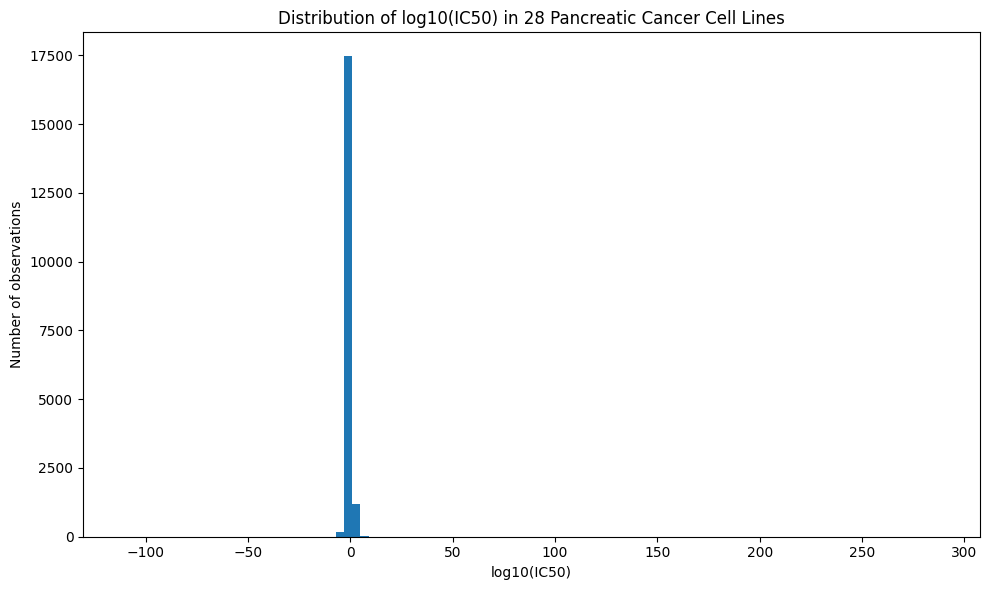

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(
    finite_pancreatic["log_ic50"],
    bins=100
)

plt.xlabel("log10(IC50)")
plt.ylabel("Number of observations")
plt.title("Distribution of log10(IC50) in 28 Pancreatic Cancer Cell Lines")

plt.tight_layout()
plt.show()

## 16. Full-Range Distribution and Zoomed Distribution

The full-range histogram demonstrates that the finite IC50 estimates span an unusually large range on the log10 scale.

However, the extreme observations compress the majority of the distribution near the center of the plot. Therefore, a second visualization is required to examine the central response distribution in greater detail.

The full-range plot is retained to document the magnitude of the observed extremes, while a zoomed plot will be used to visualize the distribution of the majority of observations.

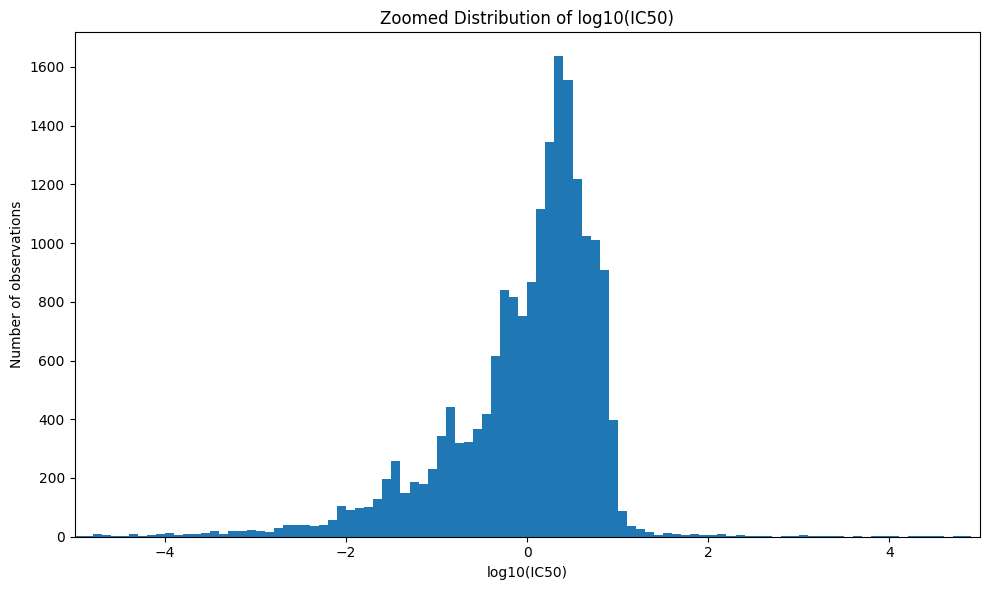

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    finite_pancreatic["log_ic50"],
    bins=100,
    range=(-5, 5)
)

plt.xlabel("log10(IC50)")
plt.ylabel("Number of observations")
plt.title("Zoomed Distribution of log10(IC50)")

plt.xlim(-5, 5)

plt.tight_layout()

plt.show()

## 17. Relationship Between IC50 Magnitude and Curve-Fit Quality

The previous analysis showed that median R² decreases in the extreme IC50 ranges.

To examine this relationship at the individual-observation level, log10(IC50) is plotted against the reported R² value.

Each point represents one finite IC50 observation from the 28 matched pancreatic cell lines.

This visualization is used to determine whether poor curve-fitting quality becomes concentrated toward the extreme IC50 tails.

The analysis remains descriptive: an association between extreme IC50 and low R² does not by itself establish that the IC50 estimate is invalid or caused by censoring.

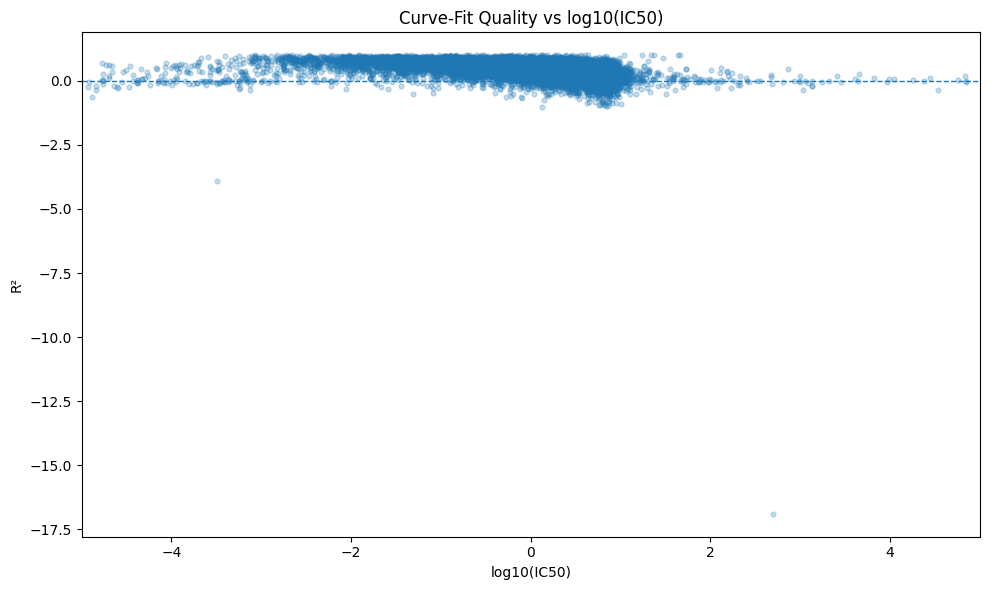

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    finite_pancreatic["log_ic50"],
    finite_pancreatic["r2"],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("log10(IC50)")
plt.ylabel("R²")
plt.title("Curve-Fit Quality vs log10(IC50)")

plt.xlim(-5, 5)

plt.tight_layout()

plt.show()

## 18. Quantifying Poor Curve Fits Across the IC50 Distribution

To quantify the relationship observed in the scatter plot, observations are grouped by log10(IC50) range.

For each range, we calculate:

- Number of observations.
- Median R².
- Percentage with R² < 0.
- Percentage with R² < 0.2.

An R² threshold of 0.2 is used here as a descriptive indicator of poor curve-fitting quality. It is not treated as a universal validity threshold for dose-response curves.

The purpose is to determine whether poor fitting becomes progressively more common toward the extreme IC50 tails.

In [17]:
fit_quality_summary = (
    finite_pancreatic
    .groupby("log_ic50_range", observed=False)
    .agg(
        N=("r2", "size"),
        Median_R2=("r2", "median"),
        Mean_R2=("r2", "mean"),
        R2_below_0=("r2", lambda x: (x < 0).mean() * 100),
        R2_below_02=("r2", lambda x: (x < 0.2).mean() * 100)
    )
    .reset_index()
)

fit_quality_summary

,log_ic50_range,N,Median_R2,Mean_R2,R2_below_0,R2_below_02
0,< -3,225,0.108885,0.226843,34.222222,54.222222
1,-3 to -2,428,0.766693,0.693731,2.803738,6.308411
2,-2 to -1,1615,0.738775,0.690050,1.114551,3.467492
3,-1 to 0,5240,0.608689,0.576298,1.698473,6.507634
4,0 to 1,11082,0.411352,0.379779,8.942429,22.613247
5,1 to 2,216,0.123736,0.156980,25.925926,58.333333
6,2 to 3,34,0.001938,-0.421490,50.000000,73.529412
7,>= 3,72,-0.012675,-0.041088,61.111111,97.222222


## 19. Curve-Fit Quality Across IC50 Ranges

The quantitative analysis shows that poor curve-fitting becomes increasingly common toward the extreme IC50 ranges.

The median R² and the proportion of observations with R² below 0.2 are therefore visualized across the predefined log10(IC50) ranges.

This provides a compact representation of the relationship between response magnitude and curve-fitting quality.

The extreme ranges should be interpreted with consideration of their sample sizes, particularly the 2–3 and ≥3 ranges.

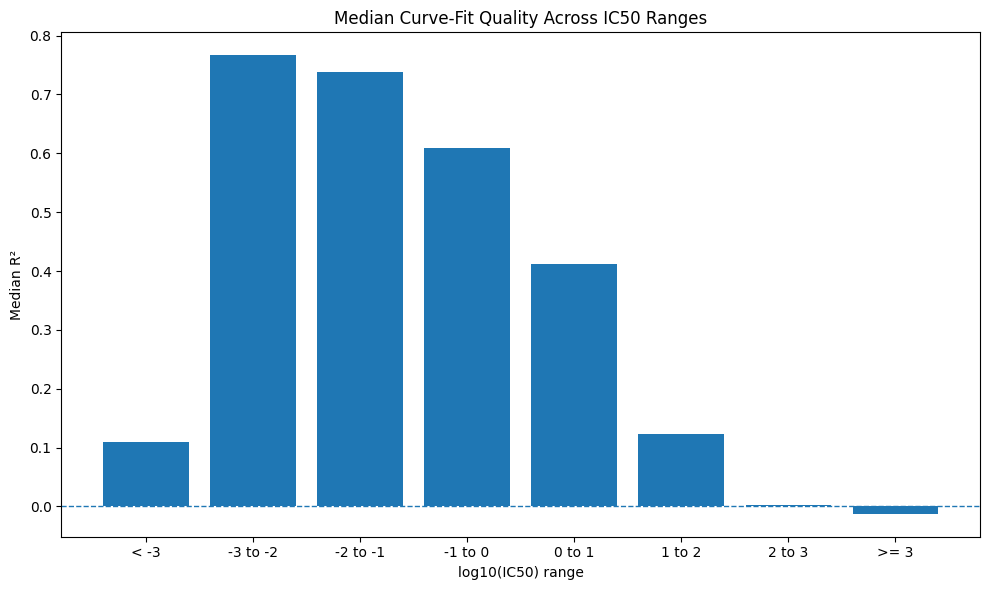

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase6_median_r2_by_ic50_range.png


In [18]:
import os
import matplotlib.pyplot as plt

# Explicit project path
project_dir = r"D:\Pancreatic_GraphTCDR"
figures_dir = os.path.join(project_dir, "results", "figures")

# Create folder if it does not exist
os.makedirs(figures_dir, exist_ok=True)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    fit_quality_summary["log_ic50_range"].astype(str),
    fit_quality_summary["Median_R2"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("log10(IC50) range")
plt.ylabel("Median R²")
plt.title("Median Curve-Fit Quality Across IC50 Ranges")

plt.tight_layout()

# Save figure
save_path = os.path.join(
    figures_dir,
    "phase6_median_r2_by_ic50_range.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

In [19]:
save_path = os.path.join(
    figures_dir,
    "phase6_median_r2_by_ic50_range.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
#Saving Diagnostic Figures
import os

figures_dir = r"D:\Pancreatic_GraphTCDR\results\figures"

os.makedirs(figures_dir, exist_ok=True)

print("Figures will be saved to:")
print(figures_dir)

Figures will be saved to:
D:\Pancreatic_GraphTCDR\results\figures


## 20. AUC Analysis

IC50 is only one summary of a dose-response curve. AUC provides an additional measure of the overall response across the tested concentration range.

AUC is therefore examined alongside log10(IC50) and R² to determine whether observations with extreme IC50 values show coherent response patterns according to another response descriptor.

AUC is treated as complementary evidence rather than as a direct measure of IC50 validity or censoring.

The analysis will compare the distribution of AUC across the predefined log10(IC50) ranges and examine whether extreme IC50 observations show systematically different AUC values.

In [21]:
auc_summary = (
    finite_pancreatic
    .groupby("log_ic50_range", observed=False)
    .agg(
        N=("auc", "size"),
        Median_AUC=("auc", "median"),
        Mean_AUC=("auc", "mean"),
        Min_AUC=("auc", "min"),
        Max_AUC=("auc", "max")
    )
    .reset_index()
)

auc_summary

,log_ic50_range,N,Median_AUC,Mean_AUC,Min_AUC,Max_AUC
0,< -3,225,0.460700,0.507632,0.021013,1.000000
1,-3 to -2,428,0.297770,0.329623,0.031491,0.906615
2,-2 to -1,1615,0.490599,0.496779,0.012733,0.919950
3,-1 to 0,5240,0.708143,0.694674,0.009001,0.927552
4,0 to 1,11082,0.876052,0.875798,0.302854,0.999891
5,1 to 2,216,0.950775,0.871053,0.012649,1.000000
6,2 to 3,34,0.724898,0.649508,0.011555,1.000000
7,>= 3,72,0.743044,0.722568,0.005819,1.000000


## 21. Relationship Between IC50 and AUC

The relationship between log10(IC50) and AUC is examined to determine whether extreme IC50 estimates correspond to systematic changes in the overall dose-response response summarized by AUC.

Because IC50 and AUC represent different characteristics of a fitted dose-response curve, agreement between them is not expected to be perfect.

The purpose of this analysis is descriptive: it will show whether extreme IC50 observations occur across a coherent range of AUC values or whether they are associated with unusually dispersed AUC measurements.

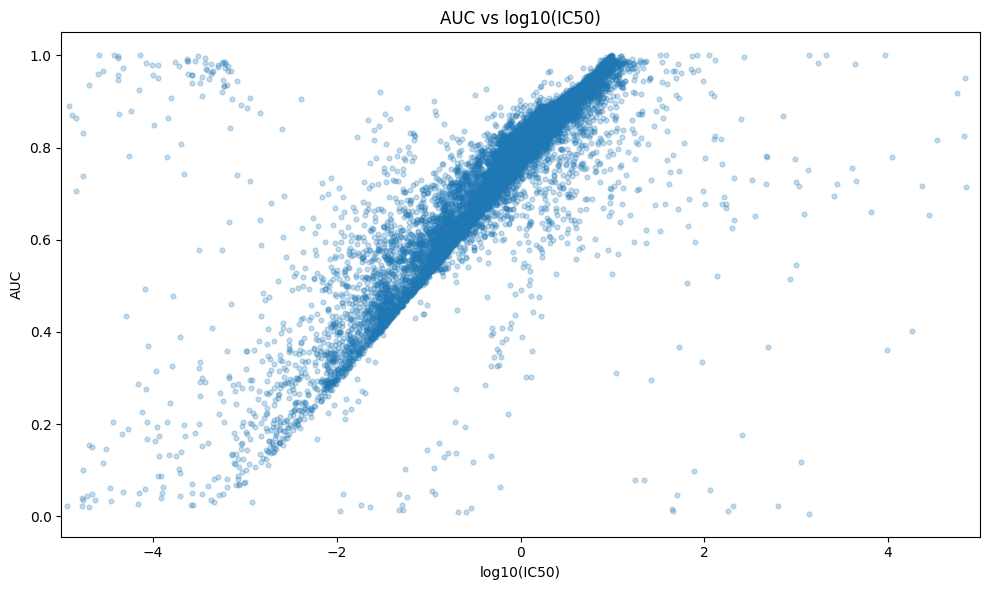

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase6_auc_vs_log_ic50.png


In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    finite_pancreatic["log_ic50"],
    finite_pancreatic["auc"],
    alpha=0.25,
    s=12
)

plt.xlabel("log10(IC50)")
plt.ylabel("AUC")
plt.title("AUC vs log10(IC50)")

plt.xlim(-5, 5)

plt.tight_layout()

save_path = os.path.join(
    figures_dir,
    "phase6_auc_vs_log_ic50.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

## 22. Drug-Level Consistency of Extreme IC50 Values

The previous analyses examined individual response observations.

The next step is to determine whether extreme IC50 values are concentrated within particular drugs.

For each drug, the number of finite IC50 observations and the number of extreme observations are calculated.

An observation is considered extreme for this descriptive analysis when:

`\[
|\log_{10}(IC50)| \geq 3
\]`


This threshold is used only to identify the extreme tail for diagnostic purposes. It is not treated as a formal biological outlier definition.

The analysis will determine whether extreme observations are broadly distributed across drugs or concentrated in a small number of compounds.

Identify extreme IC50 observations

In [23]:
finite_pancreatic["extreme_ic50"] = (
    finite_pancreatic["log_ic50"].abs() >= 3
)

drug_tail_summary = (
    finite_pancreatic
    .groupby("name")
    .agg(
        N_observations=("log_ic50", "size"),
        N_extreme=("extreme_ic50", "sum"),
        Median_log_IC50=("log_ic50", "median"),
        Median_R2=("r2", "median")
    )
    .reset_index()
)

drug_tail_summary["Extreme_percentage"] = (
    drug_tail_summary["N_extreme"] /
    drug_tail_summary["N_observations"] * 100
)

drug_tail_summary = drug_tail_summary.sort_values(
    ["N_extreme", "Extreme_percentage"],
    ascending=False
)

display(drug_tail_summary.head(20))

,name,N_observations,N_extreme,Median_log_IC50,Median_R2,Extreme_percentage
1183,triptolide,23,18,-3.588080,0.617545,78.260870
390,SN-38,20,12,-3.219213,0.370455,60.000000
878,maytansinol-isobutyrate,24,12,-3.006858,0.470561,50.000000
960,oligomycin-a,24,12,2.057882,0.023461,50.000000
485,alvespimycin,36,9,-2.665410,0.812407,25.000000
782,gemcitabine,23,8,-2.760771,0.773557,34.782609
751,filanesib,25,8,-2.532470,0.216451,32.000000
695,dolastatin-10,27,8,-2.766514,0.751411,29.629630
743,exatecan-mesylate,16,7,-2.842326,0.425542,43.750000
576,camptothecin,23,7,-1.786760,0.564999,30.434783


## 23. Concentration of Extreme Responses Across Drugs

The previous analysis shows that extreme IC50 observations are not uniformly distributed across drugs.

However, extreme-response percentages can be unstable for drugs with only a small number of observations. Therefore, drug-level concentration is examined using both the number of extreme observations and their proportion among all finite IC50 measurements.

For interpretation of drug-level percentages, drugs with very small numbers of observations should be treated cautiously.

This analysis is descriptive and is used to determine whether the long-tail observations are broadly distributed or concentrated in a subset of compounds.

Overall concentration of extreme observations across drugs

In [24]:
total_extreme = finite_pancreatic["extreme_ic50"].sum()
total_observations = len(finite_pancreatic)

print("Total finite IC50 observations:", total_observations)
print("Total extreme observations:", total_extreme)
print(
    "Percentage of all observations that are extreme:",
    round(total_extreme / total_observations * 100, 3)
)

print(
    "Number of drugs containing at least one extreme observation:",
    (drug_tail_summary["N_extreme"] > 0).sum()
)

print(
    "Total number of drugs with finite IC50:",
    len(drug_tail_summary)
)

Total finite IC50 observations: 18912
Total extreme observations: 297
Percentage of all observations that are extreme: 1.57
Number of drugs containing at least one extreme observation: 143
Total number of drugs with finite IC50: 1228


Drug-level extreme-response analysis restricted to drugs
 with at least 10 finite IC50 observations

In [25]:
drug_tail_reliable = drug_tail_summary[
    drug_tail_summary["N_observations"] >= 10
].copy()

drug_tail_reliable = drug_tail_reliable.sort_values(
    "Extreme_percentage",
    ascending=False
)

display(
    drug_tail_reliable[
        [
            "name",
            "N_observations",
            "N_extreme",
            "Extreme_percentage",
            "Median_log_IC50",
            "Median_R2"
        ]
    ].head(20)
)

,name,N_observations,N_extreme,Extreme_percentage,Median_log_IC50,Median_R2
1183,triptolide,23,18,78.260870,-3.588080,0.617545
390,SN-38,20,12,60.000000,-3.219213,0.370455
878,maytansinol-isobutyrate,24,12,50.000000,-3.006858,0.470561
960,oligomycin-a,24,12,50.000000,2.057882,0.023461
743,exatecan-mesylate,16,7,43.750000,-2.842326,0.425542
375,SB-743921,15,6,40.000000,-2.757128,0.545273
782,gemcitabine,23,8,34.782609,-2.760771,0.773557
751,filanesib,25,8,32.000000,-2.532470,0.216451
576,camptothecin,23,7,30.434783,-1.786760,0.564999
695,dolastatin-10,27,8,29.629630,-2.766514,0.751411


## 23. Drug-Level Concentration of Extreme Responses

Among the 18,912 finite IC50 observations, 297 observations (1.57%) satisfy the descriptive extreme-response criterion \(|log_{10}(IC50)| \geq 3\).

These observations occur across 143 of the 1,228 drugs with finite IC50 measurements, indicating that the extreme tail is not restricted to a small number of compounds.

However, the frequency of extreme observations varies substantially between drugs. Several compounds have a large proportion of extreme observations, while others have few or none.

Drug-level curve-fit quality also varies. Therefore, the presence of extreme IC50 values cannot be interpreted independently of R² and other response characteristics.

Drugs with very small numbers of observations are interpreted cautiously because their extreme-response percentages are unstable.

In [26]:
import os

tables_dir = r"D:\Pancreatic_GraphTCDR\results\tables"

os.makedirs(tables_dir, exist_ok=True)

print("Tables will be saved to:")
print(tables_dir)

Tables will be saved to:
D:\Pancreatic_GraphTCDR\results\tables


In [27]:
drug_table_path = os.path.join(
    tables_dir,
    "phase6_drug_level_extreme_ic50_summary.csv"
)

drug_tail_summary.to_csv(
    drug_table_path,
    index=False
)

print("Saved:", drug_table_path)

Saved: D:\Pancreatic_GraphTCDR\results\tables\phase6_drug_level_extreme_ic50_summary.csv


## 24. Separating the Lower and Upper IC50 Tails

The previous analysis combined the lower and upper extremes of the log10(IC50) distribution.

Because very low and very high IC50 estimates may arise from different response or curve-fitting behaviours, the two tails are analysed separately.

The lower tail is defined as:

\[
\log_{10}(IC50) < -3
\]

and the upper tail as:

\[
\log_{10}(IC50) \geq 3
\]

These thresholds are used only for descriptive tail characterization and are not interpreted as formal biological validity thresholds.

In [29]:
finite_pancreatic["low_extreme"] = (
    finite_pancreatic["log_ic50"] < -3
)

finite_pancreatic["high_extreme"] = (
    finite_pancreatic["log_ic50"] >= 3
)

tail_counts = pd.DataFrame({
    "Category": [
        "Lower extreme",
        "Central / non-extreme",
        "Upper extreme"
    ],
    "N": [
        finite_pancreatic["low_extreme"].sum(),
        (
            ~finite_pancreatic["low_extreme"] &
            ~finite_pancreatic["high_extreme"]
        ).sum(),
        finite_pancreatic["high_extreme"].sum()
    ]
})

tail_counts["Percentage"] = (
    tail_counts["N"] /
    len(finite_pancreatic) * 100
)

tail_counts

,Category,N,Percentage
0,Lower extreme,225,1.189721
1,Central / non-extreme,18615,98.429569
2,Upper extreme,72,0.380711


## 25. Comparing Lower and Upper IC50 Tails

The lower and upper IC50 tails are analysed separately because they differ substantially in frequency and may have different underlying causes.

For each group, the following response characteristics are compared:

- Number of observations.
- Median log10(IC50).
- Median R².
- Percentage of negative R² values.
- Percentage of R² values below 0.2.
- Median AUC.

This comparison is used to determine whether the two tails exhibit similar or different curve-fitting and response patterns.

In [30]:
tail_comparison = pd.DataFrame({
    "Category": [
        "Lower extreme",
        "Central / non-extreme",
        "Upper extreme"
    ],
    "N": [
        finite_pancreatic["low_extreme"].sum(),
        (
            ~finite_pancreatic["low_extreme"] &
            ~finite_pancreatic["high_extreme"]
        ).sum(),
        finite_pancreatic["high_extreme"].sum()
    ],
    "Median_log_IC50": [
        finite_pancreatic.loc[
            finite_pancreatic["low_extreme"],
            "log_ic50"
        ].median(),

        finite_pancreatic.loc[
            ~finite_pancreatic["low_extreme"] &
            ~finite_pancreatic["high_extreme"],
            "log_ic50"
        ].median(),

        finite_pancreatic.loc[
            finite_pancreatic["high_extreme"],
            "log_ic50"
        ].median()
    ],
    "Median_R2": [
        finite_pancreatic.loc[
            finite_pancreatic["low_extreme"],
            "r2"
        ].median(),

        finite_pancreatic.loc[
            ~finite_pancreatic["low_extreme"] &
            ~finite_pancreatic["high_extreme"],
            "r2"
        ].median(),

        finite_pancreatic.loc[
            finite_pancreatic["high_extreme"],
            "r2"
        ].median()
    ],
    "Negative_R2_%": [
        (
            finite_pancreatic.loc[
                finite_pancreatic["low_extreme"],
                "r2"
            ] < 0
        ).mean() * 100,

        (
            finite_pancreatic.loc[
                ~finite_pancreatic["low_extreme"] &
                ~finite_pancreatic["high_extreme"],
                "r2"
            ] < 0
        ).mean() * 100,

        (
            finite_pancreatic.loc[
                finite_pancreatic["high_extreme"],
                "r2"
            ] < 0
        ).mean() * 100
    ],
    "R2_below_02_%": [
        (
            finite_pancreatic.loc[
                finite_pancreatic["low_extreme"],
                "r2"
            ] < 0.2
        ).mean() * 100,

        (
            finite_pancreatic.loc[
                ~finite_pancreatic["low_extreme"] &
                ~finite_pancreatic["high_extreme"],
                "r2"
            ] < 0.2
        ).mean() * 100,

        (
            finite_pancreatic.loc[
                finite_pancreatic["high_extreme"],
                "r2"
            ] < 0.2
        ).mean() * 100
    ],
    "Median_AUC": [
        finite_pancreatic.loc[
            finite_pancreatic["low_extreme"],
            "auc"
        ].median(),

        finite_pancreatic.loc[
            ~finite_pancreatic["low_extreme"] &
            ~finite_pancreatic["high_extreme"],
            "auc"
        ].median(),

        finite_pancreatic.loc[
            finite_pancreatic["high_extreme"],
            "auc"
        ].median()
    ]
})

tail_comparison

,Category,N,Median_log_IC50,Median_R2,Negative_R2_%,R2_below_02_%,Median_AUC
0,Lower extreme,225,-3.711643,0.108885,34.222222,54.222222,0.460700
1,Central / non-extreme,18615,0.204000,0.498021,6.355090,16.551168,0.827634
2,Upper extreme,72,6.144139,-0.012675,61.111111,97.222222,0.743044


## 26. Saving the Lower–Upper Tail Comparison

The tail comparison table summarizes the differences in response magnitude, curve-fit quality, and AUC between the lower extreme, central, and upper extreme IC50 regions.

This table is retained as a diagnostic result for subsequent censoring analysis and modelling decisions.

In [31]:
tail_comparison_path = os.path.join(
    tables_dir,
    "phase6_lower_upper_tail_comparison.csv"
)

tail_comparison.to_csv(
    tail_comparison_path,
    index=False
)

print("Saved:", tail_comparison_path)

Saved: D:\Pancreatic_GraphTCDR\results\tables\phase6_lower_upper_tail_comparison.csv


## 27. Inspecting Experimental Dose Information

The fitted dose-response parameter file does not contain an explicit treatment-dose column. Therefore, the experimental concentration range cannot be inferred from the fitted `upper_limit` and `lower_limit` parameters, because these describe the fitted response curve rather than the administered drug concentrations.

The accompanying cell-line metadata file is inspected to determine whether experimental dose information or screen-design metadata are available.

If explicit dose boundaries are not available, censoring will not be assigned using an assumed concentration range.

In [32]:
cell_info_path = os.path.join(
    raw_dir,
    "secondary-screen-cell-line-info.csv"
)

cell_info = pd.read_csv(cell_info_path)

print("Shape:", cell_info.shape)
print("\nColumns:")
print(cell_info.columns.tolist())

print("\nFirst 5 rows:")
display(cell_info.head())

Shape: (588, 7)

Columns:
['row_name', 'depmap_id', 'ccle_name', 'primary_tissue', 'secondary_tissue', 'tertiary_tissue', 'passed_str_profiling']

First 5 rows:


,row_name,depmap_id,ccle_name,primary_tissue,secondary_tissue,tertiary_tissue,passed_str_profiling
0,ACH-000824,ACH-000824,KYSE510_OESOPHAGUS,esophagus,esophagus_squamous,NaN,True
1,ACH-000954,ACH-000954,HEC1A_ENDOMETRIUM,uterus,uterus_endometrium,NaN,True
2,ACH-000601,ACH-000601,MIAPACA2_PANCREAS,pancreas,NaN,NaN,True
3,ACH-000651,ACH-000651,SW620_LARGE_INTESTINE,colorectal,NaN,NaN,True
4,ACH-000361,ACH-000361,SKHEP1_LIVER,liver,NaN,NaN,True


## 28. Distinguishing Curve-Fit Parameters from Experimental Dose Boundaries

The PRISM dose-response parameter table contains fitted parameters including `upper_limit`, `lower_limit`, `slope`, `EC50`, and `IC50`.

These variables describe the fitted dose-response model and should not automatically be interpreted as the experimental concentration range.

The purpose of this analysis is therefore to determine whether the response file contains any variable that can directly recover the administered drug concentrations.

If no experimental dose variable is present, exact per-observation censoring boundaries cannot be reconstructed from the available files.

In [33]:
response_path = os.path.join(
    raw_dir,
    "secondary-screen-dose-response-curve-parameters.csv"
)

response_sample = pd.read_csv(
    response_path,
    nrows=10000
)

print("Columns:")
print(response_sample.columns.tolist())

print("\nUnique values / summary of curve parameters:")

for col in [
    "upper_limit",
    "lower_limit",
    "slope",
    "r2",
    "auc",
    "ec50",
    "ic50"
]:
    print(f"\n--- {col} ---")
    print(response_sample[col].describe())

Columns:
['broad_id', 'depmap_id', 'ccle_name', 'screen_id', 'upper_limit', 'lower_limit', 'slope', 'r2', 'auc', 'ec50', 'ic50', 'name', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase', 'passed_str_profiling', 'row_name']

Unique values / summary of curve parameters:

--- upper_limit ---
count    10000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: upper_limit, dtype: float64

--- lower_limit ---
count    10000.000000
mean         1.327102
std          1.634758
min         -2.800805
25%          0.312264
50%          1.463440
75%          1.839684
max         62.984554
Name: lower_limit, dtype: float64

--- slope ---
count    10000.000000
mean         1.399496
std          5.942308
min       -186.032426
25%         -0.227402
50%          0.004612
75%          1.910936
max        213.773093
Name: slope, dtype: float64

--- r2 ---
count    10000.000000
mean         0.190817
std          0.300

d:\Pancreatic_GraphTCDR\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


## 29. EC50–IC50 Consistency Analysis

Because the available PRISM parameter file does not contain the experimental concentration series, exact censoring boundaries cannot be reconstructed.

As an additional diagnostic, the relationship between the fitted EC50 and IC50 parameters is therefore examined.

Both quantities are transformed to log10 scale for numerical stability. The analysis compares their agreement across the central region and the lower and upper IC50 tails.

Large discrepancies between fitted EC50 and IC50, particularly when accompanied by poor R², may indicate unstable or poorly constrained curve estimates.

This analysis is considered diagnostic evidence rather than direct proof of censoring.

In [34]:
import os
import pandas as pd
import numpy as np


In [35]:
# Explicit project paths

PROJECT_DIR = r"D:\Pancreatic_GraphTCDR"

MAPPING_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "processed",
    "pancreatic28_cell_mapping.csv"
)

RESPONSE_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "raw",
    "secondary-screen-dose-response-curve-parameters.csv"
)

In [36]:
# Load the 28 GraphTCDR-matched pancreatic cell lines

pancreatic_mapping = pd.read_csv(MAPPING_PATH)

pancreatic_cell_lines = (
    pancreatic_mapping["cellLineName"]
    .dropna()
    .unique()
    .tolist()
)

print("Number of pancreatic cell lines:", len(pancreatic_cell_lines))

Number of pancreatic cell lines: 28


In [37]:
# Load only the columns needed for EC50–IC50 analysis

use_columns = [
    "depmap_id",
    "ccle_name",
    "screen_id",
    "name",
    "ec50",
    "ic50",
    "r2",
    "auc"
]

parts = []

for chunk in pd.read_csv(
    RESPONSE_PATH,
    usecols=use_columns,
    chunksize=100000
):
    
    matched = chunk[
        chunk["ccle_name"].isin(pancreatic_cell_lines)
    ].copy()

    if len(matched) > 0:
        parts.append(matched)

ec50_pancreatic = pd.concat(
    parts,
    ignore_index=True
)


In [38]:
# Report

print("\nEC50 pancreatic dataset")
print("-----------------------")
print("Shape:", ec50_pancreatic.shape)
print("Unique cell lines:", ec50_pancreatic["ccle_name"].nunique())
print("Unique drugs:", ec50_pancreatic["name"].nunique())
print("Non-missing EC50:", ec50_pancreatic["ec50"].notna().sum())
print("Non-missing IC50:", ec50_pancreatic["ic50"].notna().sum())


EC50 pancreatic dataset
-----------------------
Shape: (40119, 8)
Unique cell lines: 28
Unique drugs: 1448
Non-missing EC50: 40119
Non-missing IC50: 18913


In [39]:

# EC50–IC50 consistency analysis


ec50_ic50 = ec50_pancreatic.copy()

# Keep only positive, finite EC50 and IC50 values
valid_mask = (
    np.isfinite(ec50_ic50["ec50"]) &
    np.isfinite(ec50_ic50["ic50"]) &
    (ec50_ic50["ec50"] > 0) &
    (ec50_ic50["ic50"] > 0)
)

ec50_ic50 = ec50_ic50.loc[valid_mask].copy()

# Log-transform for numerical stability
ec50_ic50["log_ec50"] = np.log10(ec50_ic50["ec50"])
ec50_ic50["log_ic50"] = np.log10(ec50_ic50["ic50"])

# Difference between fitted EC50 and IC50
ec50_ic50["EC50_IC50_difference"] = (
    ec50_ic50["log_ec50"] -
    ec50_ic50["log_ic50"]
)

# Define the same IC50 tail categories used previously
bins = [
    -np.inf, -3, -2, -1, 0, 1, 2, 3, np.inf
]

labels = [
    "< -3",
    "-3 to -2",
    "-2 to -1",
    "-1 to 0",
    "0 to 1",
    "1 to 2",
    "2 to 3",
    ">= 3"
]

ec50_ic50["IC50_range"] = pd.cut(
    ec50_ic50["log_ic50"],
    bins=bins,
    labels=labels,
    right=False
)

# Summarize EC50–IC50 relationship
ec50_ic50_summary = (
    ec50_ic50
    .groupby("IC50_range", observed=False)
    .agg(
        N=("log_ic50", "size"),
        Median_log_IC50=("log_ic50", "median"),
        Median_log_EC50=("log_ec50", "median"),
        Median_difference=("EC50_IC50_difference", "median"),
        Median_absolute_difference=(
            "EC50_IC50_difference",
            lambda x: np.median(np.abs(x))
        ),
        Median_R2=("r2", "median")
    )
    .reset_index()
)

print("Valid EC50–IC50 observations:", len(ec50_ic50))
print("\nEC50–IC50 consistency by IC50 range:")
display(ec50_ic50_summary)

Valid EC50–IC50 observations: 18912

EC50–IC50 consistency by IC50 range:


,IC50_range,N,Median_log_IC50,Median_log_EC50,Median_difference,Median_absolute_difference,Median_R2
0,< -3,225,-3.711643,-3.285078,-0.000325,0.096190,0.108885
1,-3 to -2,428,-2.346655,-2.380691,-0.023399,0.030358,0.766693
2,-2 to -1,1615,-1.425149,-1.479702,-0.029496,0.034422,0.738775
3,-1 to 0,5240,-0.330522,-0.389042,-0.024126,0.028888,0.608689
4,0 to 1,11082,0.436568,0.374319,-0.021365,0.026785,0.411352
5,1 to 2,216,1.130148,0.813435,-0.304831,0.441418,0.123736
6,2 to 3,34,2.282246,-0.218770,-2.520523,2.725678,0.001938
7,>= 3,72,6.144139,0.951981,-5.298423,5.526503,-0.012675


## 30. EC50–IC50 Agreement Across the IC50 Distribution

The relationship between fitted log10(EC50) and log10(IC50) is visualized using the identity line \(y=x\).

Points close to the identity line indicate agreement between the two fitted parameters.

Deviations from the identity line indicate disagreement between EC50 and IC50 estimates. The analysis is particularly focused on whether disagreement increases in the extreme IC50 regions.

This visualization is diagnostic and does not by itself establish experimental dose censoring.

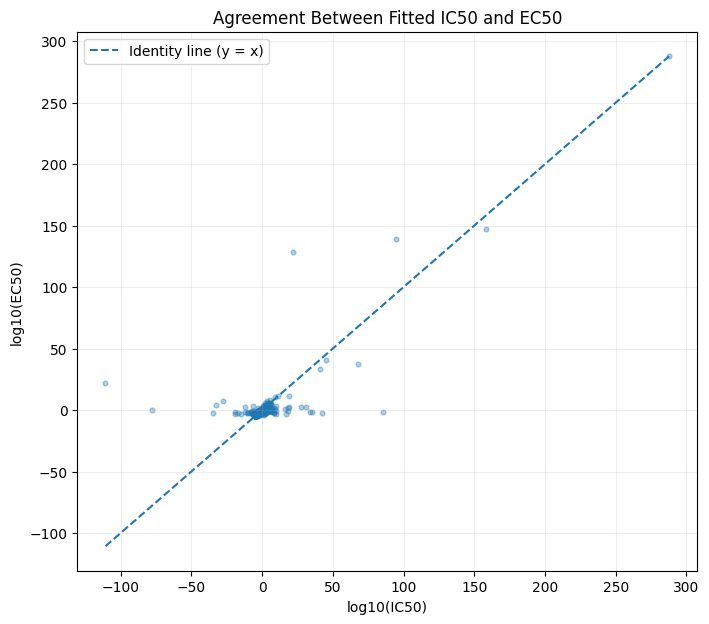

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase6_ec50_vs_ic50_agreement.png


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.figure(figsize=(8, 7))

plt.scatter(
    ec50_ic50["log_ic50"],
    ec50_ic50["log_ec50"],
    s=12,
    alpha=0.35
)

# Identity line
line_min = min(
    ec50_ic50["log_ic50"].min(),
    ec50_ic50["log_ec50"].min()
)

line_max = max(
    ec50_ic50["log_ic50"].max(),
    ec50_ic50["log_ec50"].max()
)

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    linewidth=1.5,
    label="Identity line (y = x)"
)

plt.xlabel("log10(IC50)")
plt.ylabel("log10(EC50)")
plt.title("Agreement Between Fitted IC50 and EC50")
plt.legend()
plt.grid(alpha=0.2)

save_path = os.path.join(
    r"D:\Pancreatic_GraphTCDR\results\figures",
    "phase6_ec50_vs_ic50_agreement.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

## 31. Zoomed EC50–IC50 Agreement

The full-range EC50–IC50 plot is dominated by a small number of extreme fitted values.

A second visualization therefore restricts both axes to the range -5 to 5 in log10 units. This is performed only to inspect the central relationship and does not remove extreme observations from the dataset.

The extreme observations remain retained for all quantitative analyses.

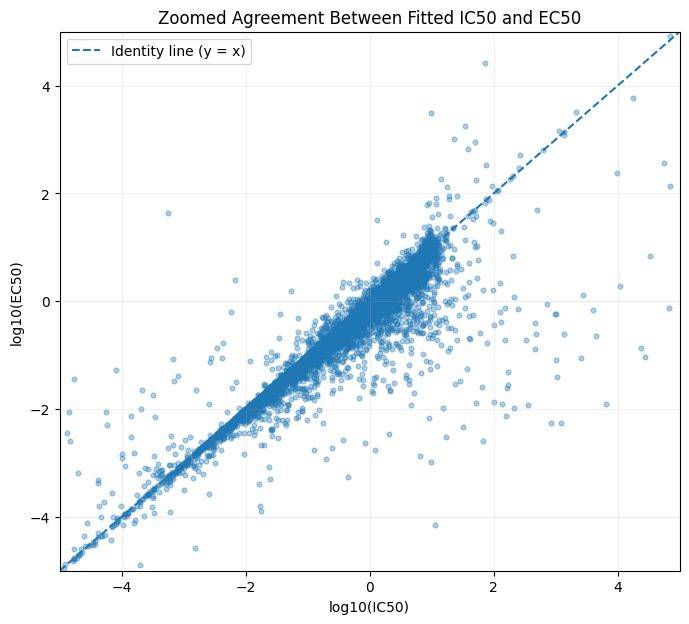

Saved: D:\Pancreatic_GraphTCDR\results\figures\phase6_ec50_vs_ic50_agreement_zoomed.png


In [41]:
plt.figure(figsize=(8, 7))

plt.scatter(
    ec50_ic50["log_ic50"],
    ec50_ic50["log_ec50"],
    s=12,
    alpha=0.35
)

# Identity line within the zoomed range
plt.plot(
    [-5, 5],
    [-5, 5],
    linestyle="--",
    linewidth=1.5,
    label="Identity line (y = x)"
)

plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.xlabel("log10(IC50)")
plt.ylabel("log10(EC50)")
plt.title("Zoomed Agreement Between Fitted IC50 and EC50")
plt.legend()
plt.grid(alpha=0.2)

save_path = os.path.join(
    r"D:\Pancreatic_GraphTCDR\results\figures",
    "phase6_ec50_vs_ic50_agreement_zoomed.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)

## 32. Quantifying EC50–IC50 Disagreement

The absolute difference between fitted log10(EC50) and log10(IC50) is calculated as a measure of disagreement between the two fitted parameters:

\[
D = |\log_{10}(EC50) - \log_{10}(IC50)|
\]

The distribution of \(D\) is compared across the lower extreme, central, and upper extreme IC50 groups.

A larger value of \(D\) indicates greater disagreement between the fitted EC50 and IC50 estimates.

This measure is used as supporting evidence for instability of extreme fitted IC50 values and is not interpreted as a direct censoring indicator.

In [42]:
# Absolute EC50–IC50 disagreement
ec50_ic50["absolute_EC50_IC50_difference"] = (
    ec50_ic50["log_ec50"] -
    ec50_ic50["log_ic50"]
).abs()

# Define the three groups
ec50_ic50["tail_group"] = np.select(
    [
        ec50_ic50["log_ic50"] < -3,
        ec50_ic50["log_ic50"] >= 3
    ],
    [
        "Lower extreme",
        "Upper extreme"
    ],
    default="Central / non-extreme"
)

# Summarize disagreement
disagreement_summary = (
    ec50_ic50
    .groupby("tail_group", observed=False)
    .agg(
        N=("absolute_EC50_IC50_difference", "size"),
        Median_absolute_difference=(
            "absolute_EC50_IC50_difference",
            "median"
        ),
        Mean_absolute_difference=(
            "absolute_EC50_IC50_difference",
            "mean"
        ),
        Q75_absolute_difference=(
            "absolute_EC50_IC50_difference",
            lambda x: x.quantile(0.75)
        ),
        Q95_absolute_difference=(
            "absolute_EC50_IC50_difference",
            lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

# Put groups in the desired order
group_order = [
    "Lower extreme",
    "Central / non-extreme",
    "Upper extreme"
]

disagreement_summary["tail_group"] = pd.Categorical(
    disagreement_summary["tail_group"],
    categories=group_order,
    ordered=True
)

disagreement_summary = (
    disagreement_summary
    .sort_values("tail_group")
    .reset_index(drop=True)
)

disagreement_summary

,tail_group,N,Median_absolute_difference,Mean_absolute_difference,Q75_absolute_difference,Q95_absolute_difference
0,Lower extreme,225,0.096190,2.521295,0.996255,9.542450
1,Central / non-extreme,18615,0.028719,0.095591,0.086200,0.365319
2,Upper extreme,72,5.526503,10.936061,10.732511,40.148102


## 33. Saving EC50–IC50 Disagreement Results

The EC50–IC50 disagreement summary is saved as a diagnostic result.

These results provide quantitative evidence that the extreme IC50 regions, particularly the upper tail, contain substantially greater disagreement between fitted EC50 and IC50 parameters than the central response region.

In [43]:
disagreement_path = os.path.join(
    r"D:\Pancreatic_GraphTCDR\results\tables",
    "phase6_ec50_ic50_disagreement_by_tail.csv"
)

disagreement_summary.to_csv(
    disagreement_path,
    index=False
)

print("Saved:", disagreement_path)

Saved: D:\Pancreatic_GraphTCDR\results\tables\phase6_ec50_ic50_disagreement_by_tail.csv


In [44]:
import os
import pandas as pd
import numpy as np

# Explicit project path
project_dir = r"D:\Pancreatic_GraphTCDR"

response_file = os.path.join(
    project_dir,
    "data",
    "raw",
    "secondary-screen-dose-response-curve-parameters.csv"
)

cell_info_file = os.path.join(
    project_dir,
    "data",
    "raw",
    "secondary-screen-cell-line-info.csv"
)

# ---------------------------------------------------------
# 1. Load only the columns we need from the raw PRISM file
# ---------------------------------------------------------
raw_needed = pd.read_csv(
    response_file,
    usecols=[
        "depmap_id",
        "ccle_name",
        "name",
        "auc",
        "r2",
        "ic50",
        "ec50",
        "lower_limit"
    ]
)

# ---------------------------------------------------------
# 2. Identify the 28 pancreatic cell lines
# ---------------------------------------------------------
cell_info = pd.read_csv(cell_info_file)

pancreatic_ids = cell_info.loc[
    cell_info["ccle_name"].str.contains(
        "PANCREAS",
        case=False,
        na=False
    ),
    "depmap_id"
].dropna().unique()

print("Pancreatic cell lines:", len(pancreatic_ids))

# ---------------------------------------------------------
# 3. Keep only pancreatic records
# ---------------------------------------------------------
analysis_df = raw_needed[
    raw_needed["depmap_id"].isin(pancreatic_ids)
].copy()

# ---------------------------------------------------------
# 4. Define finite positive IC50
# ---------------------------------------------------------
analysis_df["has_finite_ic50"] = (
    np.isfinite(analysis_df["ic50"]) &
    (analysis_df["ic50"] > 0)
)

# ---------------------------------------------------------
# 5. Summarize finite vs missing/non-finite IC50
# ---------------------------------------------------------
missing_ic50_summary = (
    analysis_df
    .groupby("has_finite_ic50")
    .agg(
        N=("auc", "size"),

        Median_AUC=("auc", "median"),
        Mean_AUC=("auc", "mean"),

        AUC_ge_1_pct=(
            "auc",
            lambda x: 100 * (x >= 1).mean()
        ),

        Median_lower_limit=(
            "lower_limit",
            "median"
        ),

        Lower_limit_gt_05_pct=(
            "lower_limit",
            lambda x: 100 * (x > 0.5).mean()
        ),

        Median_R2=("r2", "median"),

        Negative_R2_pct=(
            "r2",
            lambda x: 100 * (x < 0).mean()
        ),

        R2_below_02_pct=(
            "r2",
            lambda x: 100 * (x < 0.2).mean()
        )
    )
    .reset_index()
)

missing_ic50_summary

Pancreatic cell lines: 37


,has_finite_ic50,N,Median_AUC,Mean_AUC,AUC_ge_1_pct,Median_lower_limit,Lower_limit_gt_05_pct,Median_R2,Negative_R2_pct,R2_below_02_pct
0,False,24411,1.137794,1.156069,70.902462,1.333947,99.348654,0.027784,41.202736,78.431854
1,True,22676,0.826274,0.775007,0.008820,0.098806,0.000000,0.499891,6.650203,16.982713


In [45]:
import os
import pandas as pd
import numpy as np

# Explicit project path
project_dir = r"D:\Pancreatic_GraphTCDR"

response_file = os.path.join(
    project_dir,
    "data",
    "raw",
    "secondary-screen-dose-response-curve-parameters.csv"
)

cell_info_file = os.path.join(
    project_dir,
    "data",
    "raw",
    "secondary-screen-cell-line-info.csv"
)

# ---------------------------------------------------------
# 1. Load only the columns we need from the raw PRISM file
# ---------------------------------------------------------
raw_needed = pd.read_csv(
    response_file,
    usecols=[
        "depmap_id",
        "ccle_name",
        "name",
        "auc",
        "r2",
        "ic50",
        "ec50",
        "lower_limit"
    ]
)

# ---------------------------------------------------------
# 2. Identify the 28 pancreatic cell lines
# ---------------------------------------------------------
cell_info = pd.read_csv(cell_info_file)

pancreatic_ids = cell_info.loc[
    cell_info["ccle_name"].str.contains(
        "PANCREAS",
        case=False,
        na=False
    ),
    "depmap_id"
].dropna().unique()

print("Pancreatic cell lines:", len(pancreatic_ids))

# ---------------------------------------------------------
# 3. Keep only pancreatic records
# ---------------------------------------------------------
analysis_df = raw_needed[
    raw_needed["depmap_id"].isin(pancreatic_ids)
].copy()

# ---------------------------------------------------------
# 4. Define finite positive IC50
# ---------------------------------------------------------
analysis_df["has_finite_ic50"] = (
    np.isfinite(analysis_df["ic50"]) &
    (analysis_df["ic50"] > 0)
)

# ---------------------------------------------------------
# 5. Summarize finite vs missing/non-finite IC50
# ---------------------------------------------------------
missing_ic50_summary = (
    analysis_df
    .groupby("has_finite_ic50")
    .agg(
        N=("auc", "size"),

        Median_AUC=("auc", "median"),
        Mean_AUC=("auc", "mean"),

        AUC_ge_1_pct=(
            "auc",
            lambda x: 100 * (x >= 1).mean()
        ),

        Median_lower_limit=(
            "lower_limit",
            "median"
        ),

        Lower_limit_gt_05_pct=(
            "lower_limit",
            lambda x: 100 * (x > 0.5).mean()
        ),

        Median_R2=("r2", "median"),

        Negative_R2_pct=(
            "r2",
            lambda x: 100 * (x < 0).mean()
        ),

        R2_below_02_pct=(
            "r2",
            lambda x: 100 * (x < 0.2).mean()
        )
    )
    .reset_index()
)

missing_ic50_summary

Pancreatic cell lines: 37


,has_finite_ic50,N,Median_AUC,Mean_AUC,AUC_ge_1_pct,Median_lower_limit,Lower_limit_gt_05_pct,Median_R2,Negative_R2_pct,R2_below_02_pct
0,False,24411,1.137794,1.156069,70.902462,1.333947,99.348654,0.027784,41.202736,78.431854
1,True,22676,0.826274,0.775007,0.008820,0.098806,0.000000,0.499891,6.650203,16.982713


In [46]:
import numpy as np
import pandas as pd

# Use the dataframe that already exists
analysis_df = ec50_pancreatic.copy()

# Check that the required columns exist
required = ["ic50", "auc", "r2"]
missing = [c for c in required if c not in analysis_df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}. Available columns: {list(analysis_df.columns)}")

# Identify finite positive IC50 values
analysis_df["has_finite_ic50"] = (
    np.isfinite(analysis_df["ic50"]) &
    (analysis_df["ic50"] > 0)
)

# Compare records WITH and WITHOUT finite IC50
missing_ic50_summary = (
    analysis_df
    .groupby("has_finite_ic50")
    .agg(
        N=("ic50", "size"),
        Median_AUC=("auc", "median"),
        Mean_AUC=("auc", "mean"),
        AUC_ge_1_pct=("auc", lambda x: 100 * (x >= 1).mean()),
        Median_R2=("r2", "median"),
        Negative_R2_pct=("r2", lambda x: 100 * (x < 0).mean()),
        R2_below_02_pct=("r2", lambda x: 100 * (x < 0.2).mean())
    )
    .reset_index()
)

missing_ic50_summary

,has_finite_ic50,N,Median_AUC,Mean_AUC,AUC_ge_1_pct,Median_R2,Negative_R2_pct,R2_below_02_pct
0,False,21207,1.141009,1.160451,71.415099,0.027123,41.330693,78.634413
1,True,18912,0.826983,0.775462,0.005288,0.494767,6.895093,17.306472


In [47]:
# Final Phase 6 check:
# How does curve-fit quality change across the response distribution?

tail_quality = (
    analysis_df
    .assign(
        log_ic50=np.where(
            analysis_df["has_finite_ic50"],
            np.log10(analysis_df["ic50"]),
            np.nan
        )
    )
)

tail_quality["response_region"] = pd.cut(
    tail_quality["log_ic50"],
    bins=[-np.inf, -3, -2, -1, 0, 1, 2, 3, np.inf],
    labels=[
        "< -3",
        "-3 to -2",
        "-2 to -1",
        "-1 to 0",
        "0 to 1",
        "1 to 2",
        "2 to 3",
        "> 3"
    ]
)

tail_quality_summary = (
    tail_quality
    .dropna(subset=["response_region"])
    .groupby("response_region", observed=True)
    .agg(
        N=("r2", "size"),
        Median_R2=("r2", "median"),
        Mean_R2=("r2", "mean"),
        Negative_R2_pct=("r2", lambda x: 100 * (x < 0).mean()),
        R2_below_02_pct=("r2", lambda x: 100 * (x < 0.2).mean())
    )
    .reset_index()
)

tail_quality_summary

,response_region,N,Median_R2,Mean_R2,Negative_R2_pct,R2_below_02_pct
0,< -3,225,0.108885,0.226843,34.222222,54.222222
1,-3 to -2,428,0.766693,0.693731,2.803738,6.308411
2,-2 to -1,1615,0.738775,0.690050,1.114551,3.467492
3,-1 to 0,5240,0.608689,0.576298,1.698473,6.507634
4,0 to 1,11082,0.411352,0.379779,8.942429,22.613247
5,1 to 2,216,0.123736,0.156980,25.925926,58.333333
6,2 to 3,34,0.001938,-0.421490,50.000000,73.529412
7,> 3,72,-0.012675,-0.041088,61.111111,97.222222


## 34. Final Diagnostic Summary

The PRISM pancreatic response analysis shows a strongly heavy-tailed distribution of fitted IC50 values. Among the 18,912 finite IC50 observations, 297 observations (1.57%) fall in the extreme regions defined by \(\log_{10}(IC50) < -3\) or \(\log_{10}(IC50) \geq 3\).

Extreme IC50 values are associated with progressively poorer dose-response curve-fit quality. The upper extreme shows the strongest degradation, with a median R² close to zero and a high proportion of observations with R² < 0.2. The lower extreme also shows poorer curve-fit quality than the central response region.

Extreme observations are distributed across multiple drugs rather than being restricted to a single compound. Therefore, the observed long tail cannot be attributed solely to a small number of drugs.

AUC was examined as an additional response descriptor. It provides complementary information about the fitted dose-response behaviour but does not independently establish that an extreme IC50 value is invalid or censored.

The available PRISM curve-parameter and cell-line metadata files do not contain the experimentally administered concentration series or explicit per-observation dose boundaries. Therefore, exact experimental censoring limits cannot be reconstructed from the available data.

The EC50–IC50 analysis provides additional evidence that the extreme IC50 regions, particularly the upper tail, show substantially greater disagreement between fitted EC50 and IC50 values than the central response region. This pattern is consistent with less stable or poorly constrained fitted response estimates.

Overall, the analysis demonstrates a strong association between extreme IC50 estimates and poor curve-fit quality, but it does not establish that all extreme observations are artifacts or formally dose-censored.

Therefore, extreme observations will not be arbitrarily removed or labelled as censored. Instead, the findings motivate the investigation of quality-aware or robust modelling strategies in the subsequent modelling phase.